# Zadanie 4: obliczenia ewolucyjne

Termin realizacji: 5 maja 2025

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Zmodyfikuj przykład "iterative method" z notatnika `tsp_lazy_constraints.ipynb` z poprzednich zajęć tak, aby rozwiązywał [problem podróżującego konsumenta](https://en.wikipedia.org/wiki/Traveling_purchaser_problem). Przykładowe problemy generuje poniższa funkcja `generate_random_tpp`. Przyjmij, że wszystkie miasta muszą być odwiedzone niezależnie od tego czy dokonany tam będzie zakup czy też nie. W rozwiązaniu wypisz w którym mieście kupione będą poszczególne przedmioty oraz narysuj trasę.
2. Zmodyfikuj analogicznie kod z notatnika `tsp-genetic.ipynb` tak aby rozwiązywał ten sam problem. Porównaj wydajność (czas obliczeń i wartość funkcji kosztu) dla dziewięciu losowych problemów, po trzy dla rozmiarów (n=50, k=20), (n=50, k=50) oraz (n=100, k=100). Dobierz parametry algorytmu genetycznego tak, aby czas działania nie przekraczał w żadnym przypadku minuty.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Zaimplementuj dodatkowo [krzyżowanie PMX](https://en.wikipedia.org/wiki/Crossover_(genetic_algorithm)#Partially_mapped_crossover_(PMX)) i porównaj wydajność z tym opartym o inwersję permutacji.

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Zmodyfikuj problem tak, aby konsument nie musiał odwiedzać miast w których niczego nie kupuje.
3. Dodaj dodatkowo do porównania zmodyfikowany dla problemu podróżującego konsumenta przykład "lazy constraints" z notatnika `tsp_lazy_constraints.ipynb`.


# 4.1 Genrating tpp problem

In [82]:
using JuMP
import GLPK
import Random
import Plots

function generate_random_tpp(n, k; random_seed = 42)
    rng = Random.MersenneTwister(random_seed)
    # distance matrix
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    d = [sqrt((X[i] - X[j])^2 + (Y[i] - Y[j])^2) for i in 1:n, j in 1:n]

    cost_item_city = 50 .+ 100 .* rand(rng, k, n) # cost_item_city[num_item, num_city]

    return X, Y, d, cost_item_city
end

n = 100
k = 100
X, Y, d, cost_item_city = generate_random_tpp(n, k)
cost_item_city

100×100 Matrix{Float64}:
 121.647    80.9225   82.5522   68.4219  …   72.1259   93.1908   65.1287
 100.459   130.856   118.259    69.0424     104.262   133.856    51.3516
  67.6461   82.0081   71.3969  114.516       57.5011   54.4084  117.115
 103.59    129.142    95.4103   69.2455     100.413    92.0191  118.853
 109.536    83.7371   54.2522   82.9051      82.8586   75.2734  137.721
 145.869   130.531    75.198   111.473   …   71.9345   80.5765  142.79
 131.837   112.687   144.765    98.8433      87.3917   96.5618   76.3704
 124.573   106.05    141.785   138.105      120.424    79.8209  120.373
  83.3025   55.1765  121.658    87.9177      69.4409   51.546   105.33
 108.888    61.9168   90.1995   87.2152      65.592   107.413    92.4529
   ⋮                                     ⋱                      
 135.944   109.882   136.142   112.31        52.8428  139.026    56.2198
  73.2606  103.596   107.762   114.033       53.0942   73.7629   88.5433
  58.9109   82.205    71.1763   85.7843   

# 4.2 Iterative method - tpp

In [83]:
function build_tpp_model(d, cost_item_city, n, k)
    model = Model(GLPK.Optimizer)
    @variable(model, x[1:n, 1:n], Bin, Symmetric)
    @variable(model, y[1:k, 1:n], Bin) # y[i, j] = 1 if item i is bought in city j else y[i, j] = 0
    @objective(model, Min, sum(d .* x) / 2 + sum(cost_item_city .* y))
    @constraint(model, [i in 1:n], sum(x[i, :]) == 2)
    @constraint(model, [i in 1:n], x[i, i] == 0)
    @constraint(model, [i in 1:k], sum(y[i, :]) == 1) # each item need to be bought once
    return model
end

function subtour(edges::Vector{Tuple{Int,Int}}, n)
    shortest_subtour, unvisited = collect(1:n), Set(collect(1:n))
    while !isempty(unvisited)
        this_cycle, neighbors = Int[], unvisited
        while !isempty(neighbors)
            current = pop!(neighbors)
            push!(this_cycle, current)
            if length(this_cycle) > 1
                pop!(unvisited, current)
            end
            neighbors =
                [j for (i, j) in edges if i == current && j in unvisited]
        end
        if length(this_cycle) < length(shortest_subtour)
            shortest_subtour = this_cycle
        end
    end
    return shortest_subtour
end

function selected_edges(x::Matrix{Float64}, n)
    return Tuple{Int,Int}[(i, j) for i in 1:n, j in 1:n if x[i, j] > 0.5]
end

function bought_items(y::Matrix{Float64}, n, k)
    return sort(Tuple{Int,Int}[(i, j) for i in 1:k, j in 1:n if y[i, j] > 0.5], by = first)
end

subtour(x::Matrix{Float64}) = subtour(selected_edges(x, size(x, 1)), size(x, 1))
subtour(x::AbstractMatrix{VariableRef}) = subtour(value.(x))

function solve_tpp(X, Y, d, cost_item_city, n, k)
    iterative_model = build_tpp_model(d, cost_item_city, n, k)
    optimize!(iterative_model)
    @assert is_solved_and_feasible(iterative_model)
    time_iterated = solve_time(iterative_model)
    cycle = subtour(iterative_model[:x])
    while 1 < length(cycle) < n
        # println("Found cycle of length $(length(cycle))")
        S = [(i, j) for (i, j) in Iterators.product(cycle, cycle) if i < j]
        @constraint(
            iterative_model,
            sum(iterative_model[:x][i, j] for (i, j) in S) <= length(cycle) - 1,
        )
        optimize!(iterative_model)
        @assert is_solved_and_feasible(iterative_model)
        time_iterated += solve_time(iterative_model)
        cycle = subtour(iterative_model[:x])
    end

    obj = objective_value(iterative_model)
    return iterative_model, obj, time_iterated, X, Y
end

solve_tpp (generic function with 1 method)

1551.8368298368384
0.14099955558776855
Item 1 is bought in city 28
Item 2 is bought in city 49
Item 3 is bought in city 19
Item 4 is bought in city 18
Item 5 is bought in city 11
Item 6 is bought in city 2
Item 7 is bought in city 37
Item 8 is bought in city 13
Item 9 is bought in city 44
Item 10 is bought in city 22
Item 11 is bought in city 38
Item 12 is bought in city 31
Item 13 is bought in city 45
Item 14 is bought in city 44
Item 15 is bought in city 44
Item 16 is bought in city 29
Item 17 is bought in city 47
Item 18 is bought in city 40
Item 19 is bought in city 5
Item 20 is bought in city 6


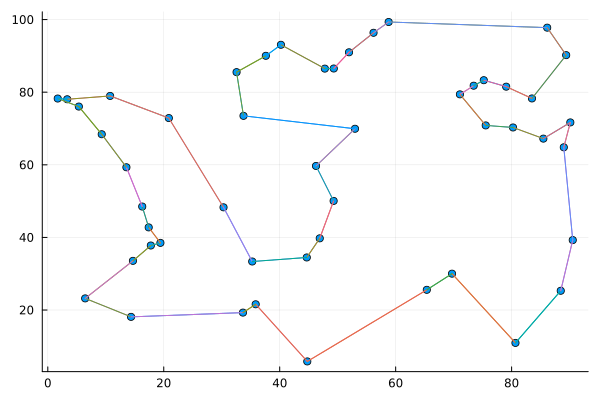

In [84]:
import JuMP: value

function plot_tour(X, Y, x)
    plot = Plots.plot()
    Plots.scatter!(X, Y)
    for (i, j) in selected_edges(x, size(x, 1))
        Plots.plot!([X[i], X[j]], [Y[i], Y[j]]; legend = false)
    end
    return plot
end

function items_info(y::Matrix{Float64}, n, k)
    for (i, j) in bought_items(y, n, k)
        println("Item $i is bought in city $j")
    end
end


X, Y, d, cost_item_city = generate_random_tpp(50, 20)
it_model, obj, time_iterated, X, Y = solve_tpp(X, Y, d, cost_item_city, 50, 20)
println(obj)
println(time_iterated)
items_info(JuMP.value.(it_model[:y]), 50, 20)
plot_tour(X, Y, JuMP.value.(it_model[:x]))

n = 50, k = 20
Item 1 is bought in city 46
Item 2 is bought in city 33
Item 3 is bought in city 41
Item 4 is bought in city 25
Item 5 is bought in city 13
Item 6 is bought in city 16
Item 7 is bought in city 16
Item 8 is bought in city 16
Item 9 is bought in city 6
Item 10 is bought in city 19
Item 11 is bought in city 2
Item 12 is bought in city 4
Item 13 is bought in city 4
Item 14 is bought in city 40
Item 15 is bought in city 25
Item 16 is bought in city 13
Item 17 is bought in city 22
Item 18 is bought in city 7
Item 19 is bought in city 14
Item 20 is bought in city 6


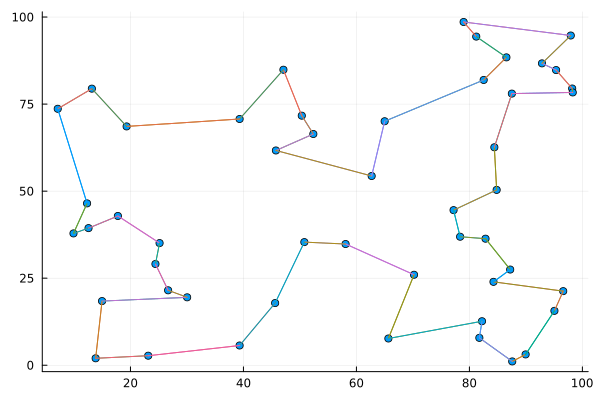

In [85]:
using DataFrames

n1, k1 = 50, 20
n2, k2 = 50, 50
n3, k3 = 100, 100
results_50_20 = []
results_50_50 = []
results_100_100 = []

println("n = $n1, k = $k1")
X, Y, d, cost_item_city = generate_random_tpp(n1, k1, random_seed=1)
it_model, obj, time_iterated, X, Y = solve_tpp(X, Y, d, cost_item_city, n1, k1)
push!(results_50_20, (obj, time_iterated))
items_info(value.(it_model[:y]), 50, 20)
plot_tour(X, Y, value.(it_model[:x]))

n = 50, k = 20
Item 1 is bought in city 39
Item 2 is bought in city 17
Item 3 is bought in city 34
Item 4 is bought in city 36
Item 5 is bought in city 36
Item 6 is bought in city 7
Item 7 is bought in city 19
Item 8 is bought in city 14
Item 9 is bought in city 27
Item 10 is bought in city 6
Item 11 is bought in city 48
Item 12 is bought in city 7
Item 13 is bought in city 16
Item 14 is bought in city 43
Item 15 is bought in city 22
Item 16 is bought in city 7
Item 17 is bought in city 17
Item 18 is bought in city 12
Item 19 is bought in city 2
Item 20 is bought in city 17


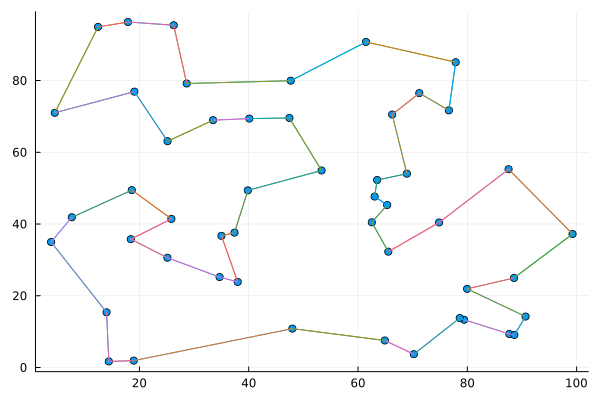

In [86]:
println("n = $n1, k = $k1")
X, Y, d, cost_item_city = generate_random_tpp(n1, k1, random_seed=2)
it_model, obj, time_iterated, X, Y = solve_tpp(X, Y, d, cost_item_city, n1, k1)
push!(results_50_20, (obj, time_iterated))
items_info(value.(it_model[:y]), 50, 20)
plot_tour(X, Y, value.(it_model[:x]))

n = 50, k = 20
Item 1 is bought in city 17
Item 2 is bought in city 8
Item 3 is bought in city 35
Item 4 is bought in city 4
Item 5 is bought in city 30
Item 6 is bought in city 20
Item 7 is bought in city 36
Item 8 is bought in city 9
Item 9 is bought in city 3
Item 10 is bought in city 27
Item 11 is bought in city 30
Item 12 is bought in city 33
Item 13 is bought in city 30
Item 14 is bought in city 45
Item 15 is bought in city 26
Item 16 is bought in city 10
Item 17 is bought in city 37
Item 18 is bought in city 1
Item 19 is bought in city 13
Item 20 is bought in city 48


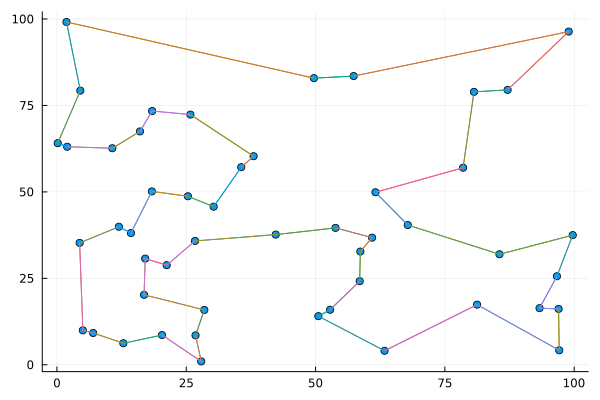

In [87]:
println("n = $n1, k = $k1")
X, Y, d, cost_item_city = generate_random_tpp(n1, k1, random_seed=3)
it_model, obj, time_iterated, X, Y = solve_tpp(X, Y, d, cost_item_city, n1, k1)
push!(results_50_20, (obj, time_iterated))
items_info(value.(it_model[:y]), 50, 20)
plot_tour(X, Y, value.(it_model[:x]))

n = 50, k = 50
Item 1 is bought in city 11
Item 2 is bought in city 38
Item 3 is bought in city 42
Item 4 is bought in city 41
Item 5 is bought in city 22
Item 6 is bought in city 30
Item 7 is bought in city 39
Item 8 is bought in city 1
Item 9 is bought in city 2
Item 10 is bought in city 12
Item 11 is bought in city 14
Item 12 is bought in city 28
Item 13 is bought in city 25
Item 14 is bought in city 5
Item 15 is bought in city 12
Item 16 is bought in city 18
Item 17 is bought in city 40
Item 18 is bought in city 28
Item 19 is bought in city 30
Item 20 is bought in city 26
Item 21 is bought in city 36
Item 22 is bought in city 20
Item 23 is bought in city 25
Item 24 is bought in city 29
Item 25 is bought in city 27
Item 26 is bought in city 36
Item 27 is bought in city 49
Item 28 is bought in city 8
Item 29 is bought in city 9
Item 30 is bought in city 50
Item 31 is bought in city 38
Item 32 is bought in city 45
Item 33 is bought in city 28
Item 34 is bought in city 16
Item 35 is bo

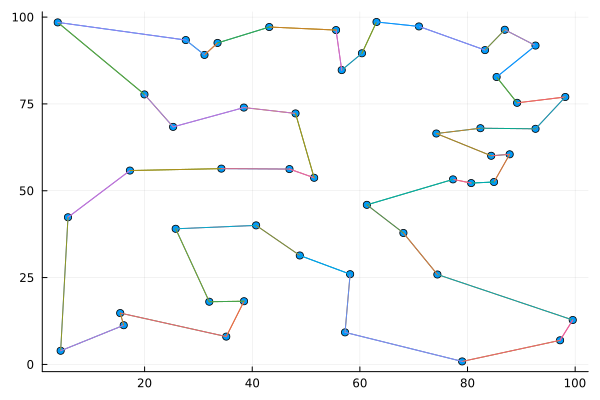

In [88]:
println("n = $n2, k = $k2")
X, Y, d, cost_item_city = generate_random_tpp(n2, k2, random_seed=4)
it_model, obj, time_iterated, X, Y = solve_tpp(X, Y, d, cost_item_city, n2, k2)
push!(results_50_50, (obj, time_iterated))
items_info(value.(it_model[:y]), n2, k2)
plot_tour(X, Y, value.(it_model[:x]))

n = 50, k = 50
Item 1 is bought in city 4
Item 2 is bought in city 18
Item 3 is bought in city 16
Item 4 is bought in city 27
Item 5 is bought in city 47
Item 6 is bought in city 4
Item 7 is bought in city 22
Item 8 is bought in city 22
Item 9 is bought in city 3
Item 10 is bought in city 29
Item 11 is bought in city 19
Item 12 is bought in city 31
Item 13 is bought in city 42
Item 14 is bought in city 46
Item 15 is bought in city 23
Item 16 is bought in city 42
Item 17 is bought in city 3
Item 18 is bought in city 12
Item 19 is bought in city 50
Item 20 is bought in city 46
Item 21 is bought in city 42
Item 22 is bought in city 12
Item 23 is bought in city 15
Item 24 is bought in city 38
Item 25 is bought in city 26
Item 26 is bought in city 35
Item 27 is bought in city 20
Item 28 is bought in city 17
Item 29 is bought in city 15
Item 30 is bought in city 26
Item 31 is bought in city 33
Item 32 is bought in city 14
Item 33 is bought in city 5
Item 34 is bought in city 34
Item 35 is bo

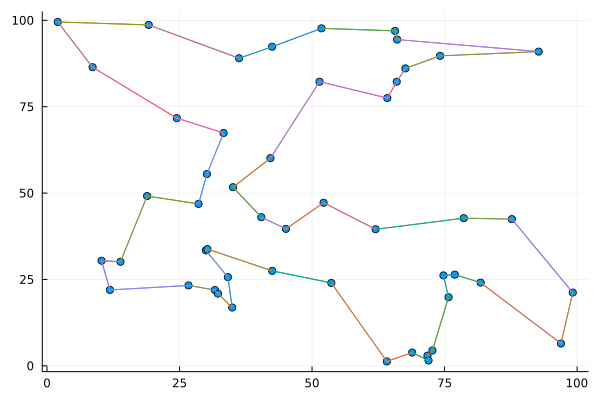

In [89]:
println("n = $n2, k = $k2")
X, Y, d, cost_item_city = generate_random_tpp(n2, k2, random_seed=5)
it_model, obj, time_iterated, X, Y = solve_tpp(X, Y, d, cost_item_city, n2, k2)
push!(results_50_50, (obj, time_iterated))
items_info(value.(it_model[:y]), n2, k2)
plot_tour(X, Y, value.(it_model[:x]))

n = 50, k = 50
Item 1 is bought in city 12
Item 2 is bought in city 17
Item 3 is bought in city 38
Item 4 is bought in city 20
Item 5 is bought in city 7
Item 6 is bought in city 26
Item 7 is bought in city 39
Item 8 is bought in city 10
Item 9 is bought in city 2
Item 10 is bought in city 2
Item 11 is bought in city 6
Item 12 is bought in city 49
Item 13 is bought in city 30
Item 14 is bought in city 36
Item 15 is bought in city 24
Item 16 is bought in city 43
Item 17 is bought in city 24
Item 18 is bought in city 36
Item 19 is bought in city 40
Item 20 is bought in city 21
Item 21 is bought in city 2
Item 22 is bought in city 29
Item 23 is bought in city 45
Item 24 is bought in city 48
Item 25 is bought in city 22
Item 26 is bought in city 8
Item 27 is bought in city 35
Item 28 is bought in city 34
Item 29 is bought in city 28
Item 30 is bought in city 45
Item 31 is bought in city 30
Item 32 is bought in city 18
Item 33 is bought in city 11
Item 34 is bought in city 17
Item 35 is bou

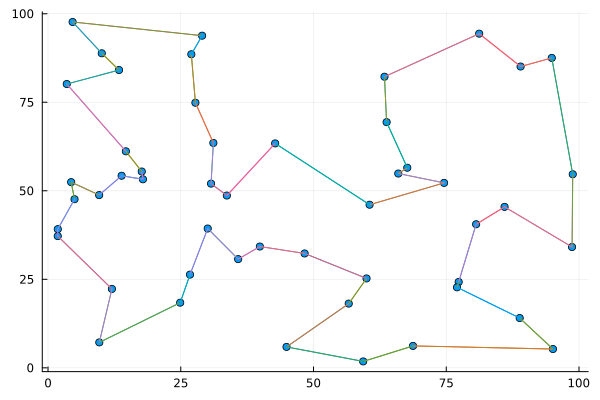

In [90]:
println("n = $n2, k = $k2")
X, Y, d, cost_item_city = generate_random_tpp(n2, k2, random_seed=6)
it_model, obj, time_iterated, X, Y = solve_tpp(X, Y, d, cost_item_city, n2, k2)
push!(results_50_50, (obj, time_iterated))
items_info(value.(it_model[:y]), n2, k2)
plot_tour(X, Y, value.(it_model[:x]))

n = 100, k = 100
Item 1 is bought in city 59
Item 2 is bought in city 72
Item 3 is bought in city 33
Item 4 is bought in city 30
Item 5 is bought in city 68
Item 6 is bought in city 65
Item 7 is bought in city 81
Item 8 is bought in city 54
Item 9 is bought in city 53
Item 10 is bought in city 73
Item 11 is bought in city 52
Item 12 is bought in city 68
Item 13 is bought in city 59
Item 14 is bought in city 84
Item 15 is bought in city 80
Item 16 is bought in city 9
Item 17 is bought in city 84
Item 18 is bought in city 61
Item 19 is bought in city 33
Item 20 is bought in city 50
Item 21 is bought in city 6
Item 22 is bought in city 30
Item 23 is bought in city 59
Item 24 is bought in city 9
Item 25 is bought in city 95
Item 26 is bought in city 15
Item 27 is bought in city 20
Item 28 is bought in city 79
Item 29 is bought in city 86
Item 30 is bought in city 83
Item 31 is bought in city 89
Item 32 is bought in city 65
Item 33 is bought in city 6
Item 34 is bought in city 2
Item 35 is 

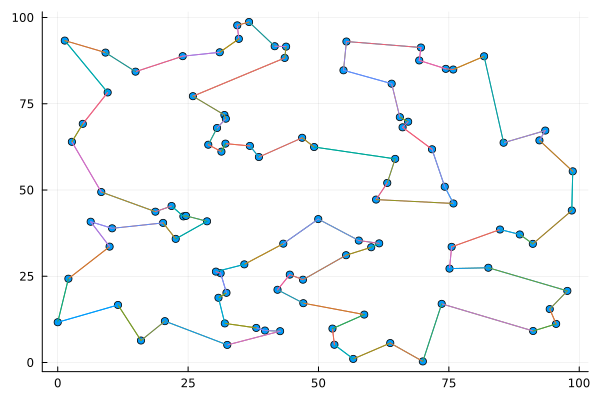

In [91]:
println("n = $n3, k = $k3")
X, Y, d, cost_item_city = generate_random_tpp(n3, k3, random_seed=7)
it_model, obj, time_iterated, X, Y = solve_tpp(X, Y, d, cost_item_city, n3, k3)
push!(results_100_100, (obj, time_iterated))
items_info(value.(it_model[:y]), n3, k3)
plot_tour(X, Y, value.(it_model[:x]))

n = 100, k = 100
Item 1 is bought in city 91
Item 2 is bought in city 20
Item 3 is bought in city 4
Item 4 is bought in city 78
Item 5 is bought in city 76
Item 6 is bought in city 60
Item 7 is bought in city 88
Item 8 is bought in city 40
Item 9 is bought in city 22
Item 10 is bought in city 64
Item 11 is bought in city 19
Item 12 is bought in city 25
Item 13 is bought in city 17
Item 14 is bought in city 91
Item 15 is bought in city 42
Item 16 is bought in city 43
Item 17 is bought in city 2
Item 18 is bought in city 12
Item 19 is bought in city 56
Item 20 is bought in city 29
Item 21 is bought in city 10
Item 22 is bought in city 29
Item 23 is bought in city 76
Item 24 is bought in city 86
Item 25 is bought in city 66
Item 26 is bought in city 82
Item 27 is bought in city 90
Item 28 is bought in city 66
Item 29 is bought in city 66
Item 30 is bought in city 93
Item 31 is bought in city 8
Item 32 is bought in city 19
Item 33 is bought in city 83
Item 34 is bought in city 80
Item 35 i

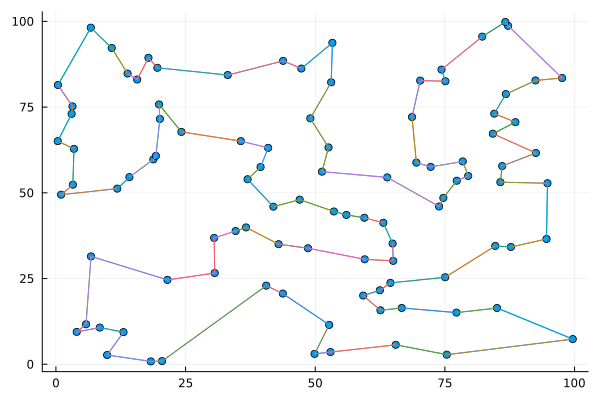

In [92]:
println("n = $n3, k = $k3")
X, Y, d, cost_item_city = generate_random_tpp(n3, k3, random_seed=8)
it_model, obj, time_iterated, X, Y = solve_tpp(X, Y, d, cost_item_city, n3, k3)
push!(results_100_100, (obj, time_iterated))
items_info(value.(it_model[:y]), n3, k3)
plot_tour(X, Y, value.(it_model[:x]))

n = 100, k = 100
Item 1 is bought in city 24
Item 2 is bought in city 63
Item 3 is bought in city 76
Item 4 is bought in city 90
Item 5 is bought in city 30
Item 6 is bought in city 69
Item 7 is bought in city 26
Item 8 is bought in city 77
Item 9 is bought in city 61
Item 10 is bought in city 98
Item 11 is bought in city 54
Item 12 is bought in city 1
Item 13 is bought in city 40
Item 14 is bought in city 74
Item 15 is bought in city 72
Item 16 is bought in city 30
Item 17 is bought in city 87
Item 18 is bought in city 36
Item 19 is bought in city 34
Item 20 is bought in city 60
Item 21 is bought in city 20
Item 22 is bought in city 86
Item 23 is bought in city 64
Item 24 is bought in city 69
Item 25 is bought in city 53
Item 26 is bought in city 40
Item 27 is bought in city 49
Item 28 is bought in city 65
Item 29 is bought in city 67
Item 30 is bought in city 50
Item 31 is bought in city 42
Item 32 is bought in city 55
Item 33 is bought in city 98
Item 34 is bought in city 17
Item 35

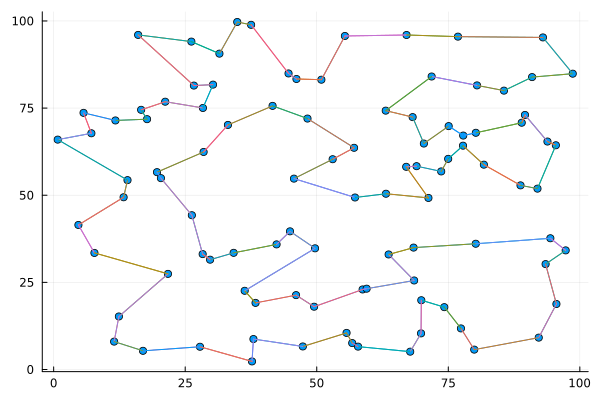

In [93]:
println("n = $n3, k = $k3")
X, Y, d, cost_item_city = generate_random_tpp(n3, k3, random_seed=9)
it_model, obj, time_iterated, X, Y = solve_tpp(X, Y, d, cost_item_city, n3, k3)
push!(results_100_100, (obj, time_iterated))
items_info(value.(it_model[:y]), n3, k3)
plot_tour(X, Y, value.(it_model[:x]))

# 4.3 Permutation inversion - tpp

In [94]:
using Evolutionary
using Random
using Plots

function generate_random_tpp(n, k; random_seed = 42)
    rng = Random.MersenneTwister(random_seed)
    # distance matrix
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    d = [sqrt((X[i] - X[j])^2 + (Y[i] - Y[j])^2) for i in 1:n, j in 1:n]

    cost_item_city = 50 .+ 100 .* rand(rng, k, n) # cost_item_city[num_item, num_city]

    return X, Y, d, cost_item_city
end

function perm_to_inv(perm::Vector)
    N = length(perm)
    inv = zeros(Int, N)
    for i in 1:N
        m = 1
        while perm[m] != i
            if perm[m] > i
                inv[i] += 1
            end
            m += 1
        end
    end
    return inv
end

function inv_to_perm(inv::Vector)
    N = length(inv)
    pos = zeros(Int, N)
    for i in N:-1:1
        for m in (i+1):N
            if pos[m] >= inv[i] + 1
                pos[m] += 1
            end
        end
        pos[i] = inv[i] + 1
    end
    perm = zeros(Int, N)
    for i in 1:N
        perm[pos[i]] = i
    end
    return perm
end

function has_subtour(perm::Vector, n)
    perm = perm[1:n]
    c = 1
    for i in 1:(length(perm)-1)
        c = perm[c]
        if c == 1
            return true
        end
    end
    return false
end

function mutate_swap(recombinant::AbstractVector;
    rng::AbstractRNG=Random.default_rng())
    N = length(recombinant)
    a = true
    while a || has_subtour(recombinant)
        i = rand(rng, 1:N)
        j = rand(rng, 1:N)
        v = recombinant[i]
        recombinant[i] = recombinant[j]
        recombinant[j] = v
        a = false
    end
    return recombinant
end

function recombine_tpp(v1::T, v2::T; rng::AbstractRNG=Random.default_rng()) where {T <: AbstractVector}
    N = length(v1)
    i1 = perm_to_inv(v1)
    i2 = perm_to_inv(v2)
    crossover_point = rand(2:(N-1))
    i1c = vcat(i1[1:crossover_point], i2[(crossover_point+1):N])
    i2c = vcat(i2[1:crossover_point], i1[(crossover_point+1):N])
    return inv_to_perm(i1c), inv_to_perm(i2c)
end

function crossover_tpp(p1, p2; rng=Random.default_rng())
    n = length(unique(p1))  
    k = length(p1) - n     

    x1, y1 = decode_individual(p1, n, k)
    x2, y2 = decode_individual(p2, n, k)

    cx1, cx2 = recombine_tpp(x1, x2; rng=rng)
    cy = rand(rng, Bool) ? y1 : y2

    return encode_individual(cx1, cy), encode_individual(cx2, cy)
end

function mutate_tpp(z; rng=Random.default_rng())
    n = length(unique(z))   
    k = length(z) - n        

    x, y = decode_individual(copy(z), n, k)
    x_mut = mutate_swap(x; rng=rng)
    y[rand(1:k)] = rand(rng, 1:n)
    return encode_individual(x_mut, y)
end

# individual will be presented as one vector [cities, items]
function encode_individual(x::Vector{Int}, y::Vector{Int})
    return vcat(x, y)
end

function decode_individual(z::Vector{Int}, n::Int, k::Int)
    x = z[1:n]
    y = z[(n+1):(n+k)]
    return x, y
end

function cost(z::Vector{Int})
    n = size(d, 1)
    k = size(cost_item_city, 1)
    x, y = decode_individual(z, n, k)

    travel_cost = 0.0
    for i in 1:length(x)
        travel_cost += d[i, x[i]]
    end

    purchase_cost = 0.0
    for item in 1:k
        city = y[item]
        purchase_cost += cost_item_city[item, city]
    end

    if has_subtour(x)
        travel_cost += 5000
    end

    return travel_cost + purchase_cost
end

#generate individual 
function random_individual(n, k)
    x = shuffle(1:n)
    y = rand(1:n, k)
    return encode_individual(x, y)
end


random_individual (generic function with 1 method)

In [95]:
n1, k1 = 50, 20
n2, k2 = 50, 50
n3, k3 = 100, 100

sol_50_20 = []
sol_50_50 = []
sol_100_100 = []

Any[]

In [96]:
using Dates
X, Y, d, cost_item_city = generate_random_tpp(50, 20, random_seed=1)

# solution is vector of visited cities and cities where item was bought so length(z) = n + k
opt_time = @elapsed begin
z_sol = Evolutionary.optimize(
    cost,
    () -> random_individual(50, 20),
    GA(; populationSize=10000, crossover=crossover_tpp, mutation=mutate_tpp, epsilon=0.01, crossoverRate=0.9),
    Evolutionary.Options(; iterations=10000)
)
end

println(has_subtour(z_sol.minimizer, 50))
println(z_sol)


false

 * Status: success

 * Candidate solution
    Minimizer:  [19, 26, 6,  ...]
    Minimum:    2885.7948714337685
    Iterations: 90

 * Found with
    Algorithm: GA[P=10000,x=0.9,μ=0.1,ɛ=0.01]

 * Convergence measures
    |f(x) - f(x')| = 0.0 ≤ 1.0e-12

 * Work counters
    Seconds run:   15.177 (vs limit Inf)
    Iterations:    90
    f(x) calls:    910000



[19, 26, 6, 28, 50, 37, 5, 1, 48, 41, 42, 30, 32, 39, 12, 15, 49, 40, 43, 27, 36, 21, 14, 17, 46, 35, 18, 29, 34, 4, 20, 45, 7, 9, 47, 24, 44, 13, 2, 38, 3, 22, 31, 23, 33, 10, 8, 11, 25, 16, 2, 15, 40, 50, 35, 50, 35, 1, 43, 20, 21, 10, 26, 40, 11, 45, 45, 25, 26, 18]
70
Item 1 is bought in city 2
Item 2 is bought in city 15
Item 3 is bought in city 40
Item 4 is bought in city 50
Item 5 is bought in city 35
Item 6 is bought in city 50
Item 7 is bought in city 35
Item 8 is bought in city 1
Item 9 is bought in city 43
Item 10 is bought in city 20
Item 11 is bought in city 21
Item 12 is bought in city 10
Item 13 is bought in city 26
Item 14 is bought in city 40
Item 15 is bought in city 11
Item 16 is bought in city 45
Item 17 is bought in city 45
Item 18 is bought in city 25
Item 19 is bought in city 26
Item 20 is bought in city 18


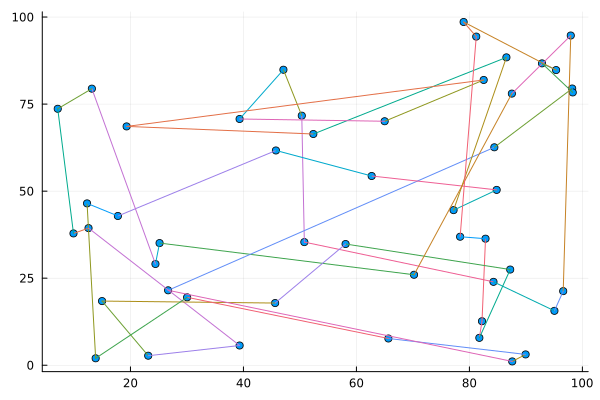

In [97]:
println(z_sol.minimizer)
println(size(z_sol.minimizer, 1))

push!(sol_50_20, (z_sol.minimum, opt_time))


function plot_tour(X, Y, x)
    plot = Plots.plot()
    scatter!(X, Y)
    for i in 1:length(x)
        j = x[i]
        Plots.plot!(plot, [X[i], X[j]], [Y[i], Y[j]]; legend = false)
    end
    return plot
end

function info_items(y)
    for i in 1:length(y)
        city = y[i]
        println("Item $i is bought in city $city")
    end
end

info_items(z_sol.minimizer[51:70])
plot_tour(X, Y, z_sol.minimizer[1:50])



In [98]:
X, Y, d, cost_item_city = generate_random_tpp(n1, k1, random_seed=2)

# solution is vector of visited cities and cities where item was bought so length(z) = n + k
opt_time = @elapsed begin
z_sol = Evolutionary.optimize(
    cost,
    () -> random_individual(n1, k1),
    GA(; populationSize=10000, crossover=crossover_tpp, mutation=mutate_tpp, epsilon=0.01, crossoverRate=0.9),
    Evolutionary.Options(; iterations=10000)
)
end

println(has_subtour(z_sol.minimizer, n1))
println(z_sol)

false

 * Status: success

 * Candidate solution
    Minimizer:  [35, 29, 7,  ...]
    Minimum:    3022.3507811686486
    Iterations: 41

 * Found with
    Algorithm: GA[P=10000,x=0.9,μ=0.1,ɛ=0.01]

 * Convergence measures
    |f(x) - f(x')| = 0.0 ≤ 1.0e-12

 * Work counters
    Seconds run:   7.194 (vs limit Inf)
    Iterations:    41
    f(x) calls:    420000



Item 1 is bought in city 32
Item 2 is bought in city 18
Item 3 is bought in city 23
Item 4 is bought in city 44
Item 5 is bought in city 36
Item 6 is bought in city 14
Item 7 is bought in city 36
Item 8 is bought in city 7
Item 9 is bought in city 7
Item 10 is bought in city 17
Item 11 is bought in city 49
Item 12 is bought in city 10
Item 13 is bought in city 39
Item 14 is bought in city 5
Item 15 is bought in city 22
Item 16 is bought in city 15
Item 17 is bought in city 15
Item 18 is bought in city 10
Item 19 is bought in city 14
Item 20 is bought in city 48


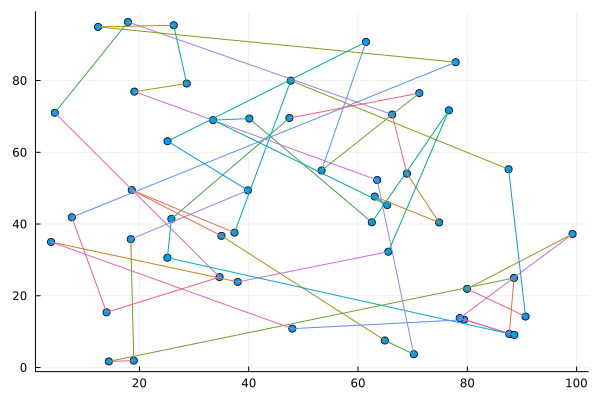

In [99]:
push!(sol_50_20, (z_sol.minimum, opt_time))
info_items(z_sol.minimizer[n1 + 1:n1 + k1])
plot_tour(X, Y, z_sol.minimizer[1:n1])

In [100]:
X, Y, d, cost_item_city = generate_random_tpp(n1, k1, random_seed=3)

# solution is vector of visited cities and cities where item was bought so length(z) = n + k
opt_time = @elapsed begin
z_sol = Evolutionary.optimize(
    cost,
    () -> random_individual(n1, k1),
    GA(; populationSize=10000, crossover=crossover_tpp, mutation=mutate_tpp, epsilon=0.01, crossoverRate=0.9),
    Evolutionary.Options(; iterations=10000)
)
end

println(has_subtour(z_sol.minimizer, n1))
println(z_sol)

false

 * Status: success

 * Candidate solution
    Minimizer:  [31, 15, 47,  ...]
    Minimum:    3005.1061157519443
    Iterations: 101

 * Found with
    Algorithm: GA[P=10000,x=0.9,μ=0.1,ɛ=0.01]

 * Convergence measures
    |f(x) - f(x')| = 0.0 ≤ 1.0e-12

 * Work counters
    Seconds run:   15.559 (vs limit Inf)
    Iterations:    101
    f(x) calls:    1020000



Item 1 is bought in city 18
Item 2 is bought in city 3
Item 3 is bought in city 15
Item 4 is bought in city 4
Item 5 is bought in city 30
Item 6 is bought in city 25
Item 7 is bought in city 42
Item 8 is bought in city 1
Item 9 is bought in city 15
Item 10 is bought in city 22
Item 11 is bought in city 42
Item 12 is bought in city 33
Item 13 is bought in city 46
Item 14 is bought in city 46
Item 15 is bought in city 34
Item 16 is bought in city 42
Item 17 is bought in city 26
Item 18 is bought in city 41
Item 19 is bought in city 31
Item 20 is bought in city 39


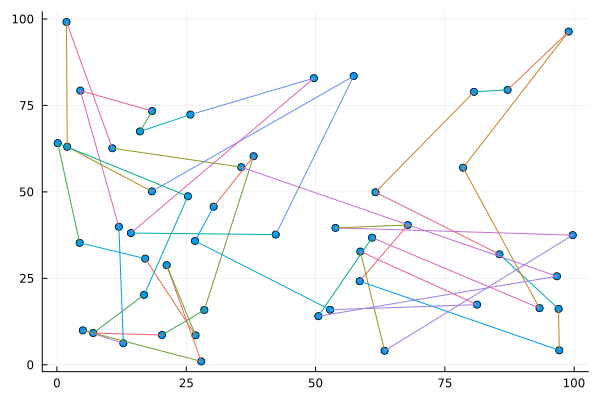

In [101]:
push!(sol_50_20, (z_sol.minimum, opt_time))
info_items(z_sol.minimizer[n1 + 1:n1 + k1])
plot_tour(X, Y, z_sol.minimizer[1:n1])

In [102]:
X, Y, d, cost_item_city = generate_random_tpp(n2, k2, random_seed=4)

# solution is vector of visited cities and cities where item was bought so length(z) = n + k
opt_time = @elapsed begin
z_sol = Evolutionary.optimize(
    cost,
    () -> random_individual(n2, k2),
    GA(; populationSize=10000, crossover=crossover_tpp, mutation=mutate_tpp, epsilon=0.01, crossoverRate=0.9),
    Evolutionary.Options(; iterations=10000)
)
end

println(has_subtour(z_sol.minimizer, n2))
println(z_sol)

false

 * Status: success

 * Candidate solution
    Minimizer:  [38, 44, 17,  ...]
    Minimum:    5822.19623781546
    Iterations: 76

 * Found with
    Algorithm: GA[P=10000,x=0.9,μ=0.1,ɛ=0.01]

 * Convergence measures
    |f(x) - f(x')| = 0.0 ≤ 1.0e-12

 * Work counters
    Seconds run:   16.626 (vs limit Inf)
    Iterations:    76
    f(x) calls:    770000



Item 1 is bought in city 9
Item 2 is bought in city 33
Item 3 is bought in city 46
Item 4 is bought in city 41
Item 5 is bought in city 17
Item 6 is bought in city 29
Item 7 is bought in city 26
Item 8 is bought in city 50
Item 9 is bought in city 47
Item 10 is bought in city 14
Item 11 is bought in city 50
Item 12 is bought in city 5
Item 13 is bought in city 2
Item 14 is bought in city 32
Item 15 is bought in city 50
Item 16 is bought in city 7
Item 17 is bought in city 22
Item 18 is bought in city 10
Item 19 is bought in city 9
Item 20 is bought in city 44
Item 21 is bought in city 5
Item 22 is bought in city 2
Item 23 is bought in city 37
Item 24 is bought in city 7
Item 25 is bought in city 5
Item 26 is bought in city 19
Item 27 is bought in city 19
Item 28 is bought in city 23
Item 29 is bought in city 36
Item 30 is bought in city 40
Item 31 is bought in city 4
Item 32 is bought in city 43
Item 33 is bought in city 31
Item 34 is bought in city 24
Item 35 is bought in city 46
Item

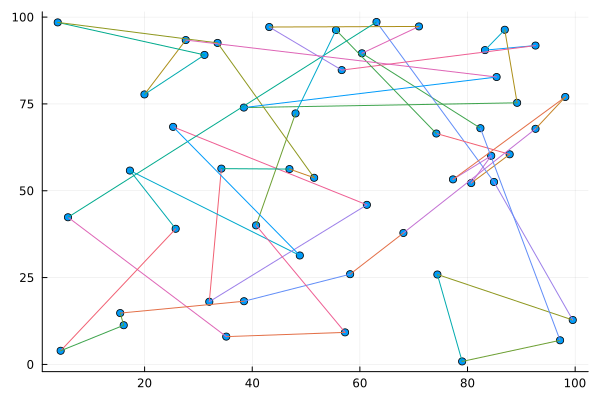

In [103]:
push!(sol_50_50, (z_sol.minimum, opt_time))
info_items(z_sol.minimizer[n2 + 1:n2 + k2])
plot_tour(X, Y, z_sol.minimizer[1:n2])

In [104]:
X, Y, d, cost_item_city = generate_random_tpp(n2, k2, random_seed=5)

# solution is vector of visited cities and cities where item was bought so length(z) = n + k
opt_time = @elapsed begin
z_sol = Evolutionary.optimize(
    cost,
    () -> random_individual(n2, k2),
    GA(; populationSize=10000, crossover=crossover_tpp, mutation=mutate_tpp, epsilon=0.01, crossoverRate=0.9),
    Evolutionary.Options(; iterations=10000)
)
end

println(has_subtour(z_sol.minimizer, n2))
println(z_sol)

false

 * Status: success

 * Candidate solution
    Minimizer:  [18, 23, 24,  ...]
    Minimum:    5765.857182113949
    Iterations: 54

 * Found with
    Algorithm: GA[P=10000,x=0.9,μ=0.1,ɛ=0.01]

 * Convergence measures
    |f(x) - f(x')| = 0.0 ≤ 1.0e-12

 * Work counters
    Seconds run:   12.421 (vs limit Inf)
    Iterations:    54
    f(x) calls:    550000



Item 1 is bought in city 30
Item 2 is bought in city 21
Item 3 is bought in city 28
Item 4 is bought in city 42
Item 5 is bought in city 31
Item 6 is bought in city 3
Item 7 is bought in city 3
Item 8 is bought in city 7
Item 9 is bought in city 37
Item 10 is bought in city 24
Item 11 is bought in city 28
Item 12 is bought in city 32
Item 13 is bought in city 9
Item 14 is bought in city 30
Item 15 is bought in city 16
Item 16 is bought in city 38
Item 17 is bought in city 19
Item 18 is bought in city 5
Item 19 is bought in city 47
Item 20 is bought in city 28
Item 21 is bought in city 11
Item 22 is bought in city 23
Item 23 is bought in city 41
Item 24 is bought in city 3
Item 25 is bought in city 5
Item 26 is bought in city 41
Item 27 is bought in city 32
Item 28 is bought in city 11
Item 29 is bought in city 23
Item 30 is bought in city 15
Item 31 is bought in city 11
Item 32 is bought in city 36
Item 33 is bought in city 36
Item 34 is bought in city 33
Item 35 is bought in city 8
It

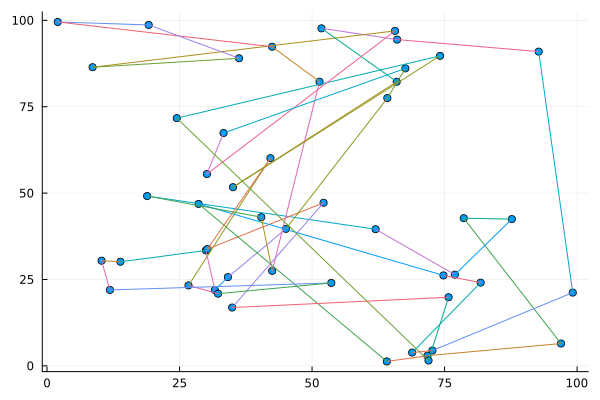

In [105]:
push!(sol_50_50, (z_sol.minimum, opt_time))
info_items(z_sol.minimizer[n2 + 1:n2 + k2])
plot_tour(X, Y, z_sol.minimizer[1:n2])

In [106]:
X, Y, d, cost_item_city = generate_random_tpp(n2, k2, random_seed=6)

# solution is vector of visited cities and cities where item was bought so length(z) = n + k
opt_time = @elapsed begin
z_sol = Evolutionary.optimize(
    cost,
    () -> random_individual(n2, k2),
    GA(; populationSize=10000, crossover=crossover_tpp, mutation=mutate_tpp, epsilon=0.01, crossoverRate=0.9),
    Evolutionary.Options(; iterations=10000)
)
end

println(has_subtour(z_sol.minimizer, n2))
println(z_sol)

false

 * Status: success

 * Candidate solution
    Minimizer:  [50, 18, 34,  ...]
    Minimum:    5831.051754989137
    Iterations: 61

 * Found with
    Algorithm: GA[P=10000,x=0.9,μ=0.1,ɛ=0.01]

 * Convergence measures
    |f(x) - f(x')| = 0.0 ≤ 1.0e-12

 * Work counters
    Seconds run:   13.111 (vs limit Inf)
    Iterations:    61
    f(x) calls:    620000



Item 1 is bought in city 17
Item 2 is bought in city 29
Item 3 is bought in city 38
Item 4 is bought in city 30
Item 5 is bought in city 21
Item 6 is bought in city 27
Item 7 is bought in city 41
Item 8 is bought in city 31
Item 9 is bought in city 25
Item 10 is bought in city 6
Item 11 is bought in city 23
Item 12 is bought in city 31
Item 13 is bought in city 45
Item 14 is bought in city 33
Item 15 is bought in city 14
Item 16 is bought in city 8
Item 17 is bought in city 42
Item 18 is bought in city 44
Item 19 is bought in city 4
Item 20 is bought in city 17
Item 21 is bought in city 16
Item 22 is bought in city 1
Item 23 is bought in city 14
Item 24 is bought in city 20
Item 25 is bought in city 36
Item 26 is bought in city 47
Item 27 is bought in city 46
Item 28 is bought in city 43
Item 29 is bought in city 14
Item 30 is bought in city 42
Item 31 is bought in city 22
Item 32 is bought in city 45
Item 33 is bought in city 2
Item 34 is bought in city 24
Item 35 is bought in city 26

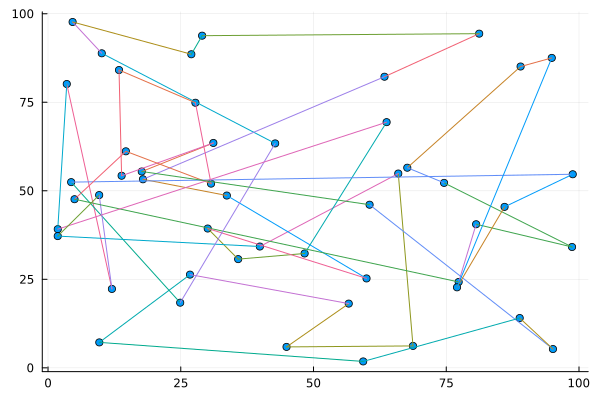

In [107]:
push!(sol_50_50, (z_sol.minimum, opt_time))
info_items(z_sol.minimizer[n2 + 1:n2 + k2])
plot_tour(X, Y, z_sol.minimizer[1:n2])

In [108]:
X, Y, d, cost_item_city = generate_random_tpp(n3, k3, random_seed=7)

# solution is vector of visited cities and cities where item was bought so length(z) = n + k
opt_time = @elapsed begin
z_sol = Evolutionary.optimize(
    cost,
    () -> random_individual(n3, k3),
    GA(; populationSize=10000, crossover=crossover_tpp, mutation=mutate_tpp, epsilon=0.01, crossoverRate=0.9),
    Evolutionary.Options(; iterations=10000)
)
end

println(has_subtour(z_sol.minimizer, n3))
println(z_sol)

false

 * Status: success

 * Candidate solution
    Minimizer:  [46, 50, 93,  ...]
    Minimum:    12458.752889378404
    Iterations: 82

 * Found with
    Algorithm: GA[P=10000,x=0.9,μ=0.1,ɛ=0.01]

 * Convergence measures
    |f(x) - f(x')| = 0.0 ≤ 1.0e-12

 * Work counters
    Seconds run:   37.076 (vs limit Inf)
    Iterations:    82
    f(x) calls:    830000



Item 1 is bought in city 43
Item 2 is bought in city 84
Item 3 is bought in city 64
Item 4 is bought in city 73
Item 5 is bought in city 55
Item 6 is bought in city 42
Item 7 is bought in city 82
Item 8 is bought in city 33
Item 9 is bought in city 72
Item 10 is bought in city 5
Item 11 is bought in city 68
Item 12 is bought in city 99
Item 13 is bought in city 1
Item 14 is bought in city 84
Item 15 is bought in city 34
Item 16 is bought in city 72
Item 17 is bought in city 84
Item 18 is bought in city 53
Item 19 is bought in city 43
Item 20 is bought in city 79
Item 21 is bought in city 10
Item 22 is bought in city 32
Item 23 is bought in city 99
Item 24 is bought in city 25
Item 25 is bought in city 6
Item 26 is bought in city 75
Item 27 is bought in city 35
Item 28 is bought in city 39
Item 29 is bought in city 27
Item 30 is bought in city 78
Item 31 is bought in city 26
Item 32 is bought in city 94
Item 33 is bought in city 90
Item 34 is bought in city 51
Item 35 is bought in city 

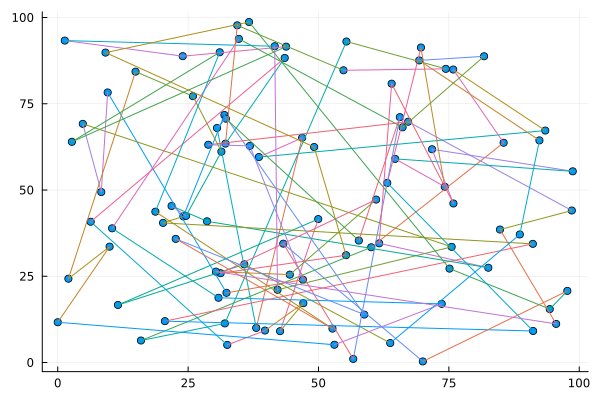

In [109]:
push!(sol_100_100, (z_sol.minimum, opt_time))
info_items(z_sol.minimizer[n3 + 1:n3 + k3])
plot_tour(X, Y, z_sol.minimizer[1:n3])

In [110]:
X, Y, d, cost_item_city = generate_random_tpp(n3, k3, random_seed=8)

# solution is vector of visited cities and cities where item was bought so length(z) = n + k
opt_time = @elapsed begin
z_sol = Evolutionary.optimize(
    cost,
    () -> random_individual(n3, k3),
    GA(; populationSize=10000, crossover=crossover_tpp, mutation=mutate_tpp, epsilon=0.01, crossoverRate=0.9),
    Evolutionary.Options(; iterations=10000)
)
end

println(has_subtour(z_sol.minimizer, n3))
println(z_sol)

false

 * Status: success

 * Candidate solution
    Minimizer:  [83, 23, 75,  ...]
    Minimum:    12307.563476863112
    Iterations: 74

 * Found with
    Algorithm: GA[P=10000,x=0.9,μ=0.1,ɛ=0.01]

 * Convergence measures
    |f(x) - f(x')| = 0.0 ≤ 1.0e-12

 * Work counters
    Seconds run:   31.617 (vs limit Inf)
    Iterations:    74
    f(x) calls:    750000



Item 1 is bought in city 100
Item 2 is bought in city 34
Item 3 is bought in city 9
Item 4 is bought in city 20
Item 5 is bought in city 35
Item 6 is bought in city 53
Item 7 is bought in city 91
Item 8 is bought in city 56
Item 9 is bought in city 35
Item 10 is bought in city 32
Item 11 is bought in city 98
Item 12 is bought in city 16
Item 13 is bought in city 9
Item 14 is bought in city 54
Item 15 is bought in city 62
Item 16 is bought in city 15
Item 17 is bought in city 78
Item 18 is bought in city 12
Item 19 is bought in city 24
Item 20 is bought in city 50
Item 21 is bought in city 89
Item 22 is bought in city 81
Item 23 is bought in city 69
Item 24 is bought in city 70
Item 25 is bought in city 50
Item 26 is bought in city 75
Item 27 is bought in city 87
Item 28 is bought in city 32
Item 29 is bought in city 20
Item 30 is bought in city 54
Item 31 is bought in city 34
Item 32 is bought in city 87
Item 33 is bought in city 74
Item 34 is bought in city 48
Item 35 is bought in cit

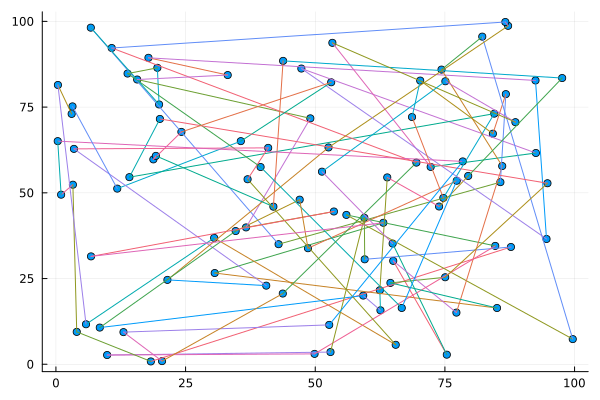

In [111]:
push!(sol_100_100, (z_sol.minimum, opt_time))
info_items(z_sol.minimizer[n3 + 1:n3 + k3])
plot_tour(X, Y, z_sol.minimizer[1:n3])

In [112]:
X, Y, d, cost_item_city = generate_random_tpp(n3, k3, random_seed=9)

# solution is vector of visited cities and cities where item was bought so length(z) = n + k
opt_time = @elapsed begin
z_sol = Evolutionary.optimize(
    cost,
    () -> random_individual(n3, k3),
    GA(; populationSize=10000, crossover=crossover_tpp, mutation=mutate_tpp, epsilon=0.01, crossoverRate=0.9),
    Evolutionary.Options(; iterations=10000)
)
end

println(has_subtour(z_sol.minimizer, n3))
println(z_sol)

false

 * Status: success

 * Candidate solution
    Minimizer:  [50, 100, 4,  ...]
    Minimum:    12095.346310259034
    Iterations: 109

 * Found with
    Algorithm: GA[P=10000,x=0.9,μ=0.1,ɛ=0.01]

 * Convergence measures
    |f(x) - f(x')| = 0.0 ≤ 1.0e-12

 * Work counters
    Seconds run:   44.645 (vs limit Inf)
    Iterations:    109
    f(x) calls:    1100000



Item 1 is bought in city 71
Item 2 is bought in city 53
Item 3 is bought in city 70
Item 4 is bought in city 30
Item 5 is bought in city 48
Item 6 is bought in city 70
Item 7 is bought in city 44
Item 8 is bought in city 86
Item 9 is bought in city 5
Item 10 is bought in city 97
Item 11 is bought in city 92
Item 12 is bought in city 99
Item 13 is bought in city 87
Item 14 is bought in city 90
Item 15 is bought in city 25
Item 16 is bought in city 61
Item 17 is bought in city 55
Item 18 is bought in city 43
Item 19 is bought in city 89
Item 20 is bought in city 44
Item 21 is bought in city 67
Item 22 is bought in city 62
Item 23 is bought in city 25
Item 24 is bought in city 27
Item 25 is bought in city 53
Item 26 is bought in city 30
Item 27 is bought in city 25
Item 28 is bought in city 5
Item 29 is bought in city 35
Item 30 is bought in city 24
Item 31 is bought in city 68
Item 32 is bought in city 26
Item 33 is bought in city 83
Item 34 is bought in city 56
Item 35 is bought in city

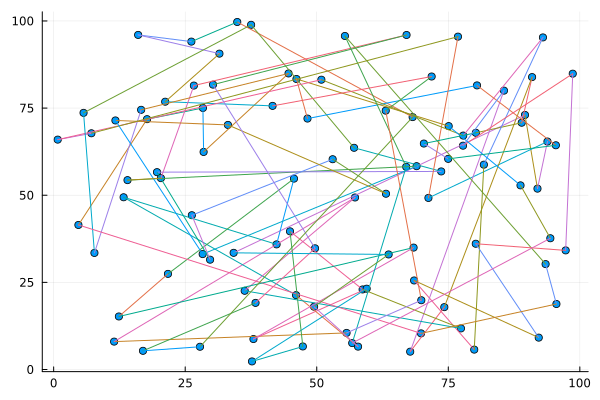

In [113]:
push!(sol_100_100, (z_sol.minimum, opt_time))
info_items(z_sol.minimizer[n3 + 1:n3 + k3])
plot_tour(X, Y, z_sol.minimizer[1:n3])

In [114]:
df = DataFrame(Iterative_method_50_20=results_50_20, 
    Iterative_method_50_50=results_50_50, 
    Iterative_method_100_100=results_100_100,
    Genetic_50_20=sol_50_20,
    Genetic_50_50=sol_50_50,
    Genetic_100_100=sol_100_100)

Row,Iterative_method_50_20,Iterative_method_50_50,Iterative_method_100_100,Genetic_50_20,Genetic_50_50,Genetic_100_100
,Any,Any,Any,Any,Any,Any
1,"(1569.95, 0.0229998)","(3239.97, 0.401999)","(5860.38, 345.006)","(2885.79, 15.6968)","(5822.2, 16.7641)","(12458.8, 37.3351)"
2,"(1612.07, 0.791)","(3149.27, 3.512)","(5890.58, 12.798)","(3022.35, 7.28108)","(5765.86, 12.5452)","(12307.6, 32.0973)"
3,"(1679.49, 0.0829999)","(3190.33, 3.426)","(5899.56, 19.255)","(3005.11, 15.9888)","(5831.05, 13.2644)","(12095.3, 44.8746)"
